# 05 · Resultados, análisis y figuras
Este notebook regenera las figuras 2, 3, 4, 8, 9 y 10 a partir de los derivados auditables. Los gráficos estáticos se guardan en SVG y PNG. El mapa interactivo contiene sus propias geometrías y JavaScript; funciona sin red ni servicios externos.

In [1]:
import sys, json
from pathlib import Path
RAIZ = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ / 'src'))
import numpy as np
import pandas as pd
import config as c
from IPython.display import display, Image, IFrame
pd.set_option('display.max_columns', 20)
from simulacion import cargar_cache
from analisis import figuras, principales
cache=cargar_cache()
resultado=json.loads((c.DERIVADOS/'04_resultados.json').read_text())
vehiculos=dict(np.load(c.DERIVADOS/'04_vehiculos.npz'))
matrices=pd.read_csv(c.DERIVADOS/'04_matrices.csv')
tablas=figuras(cache,resultado,vehiculos,matrices)
resumen=principales(resultado)
display(resumen[['escenario','metrica','delta_pct','ic_pareado','delta_libre_pct','reduccion_ancho_pct','p_sin_ruta']])


,escenario,metrica,delta_pct,ic_pareado,delta_libre_pct,reduccion_ancho_pct,p_sin_ruta
0,reforma,mediana,-0.678379,"[-0.7661938589733648, -0.5881524854342794]",0.089940,83.554529,0.0
1,reforma,p95,1.864653,"[1.6821918059172851, 2.043871848317961]",0.894918,58.944932,0.0
2,reforma,red_total,0.002497,"[-0.03808868128726449, 0.04237203449578258]",0.809664,95.657239,0.0
3,vista_hermosa,mediana,55.402445,"[54.963789067037446, 55.820923563599216]",47.788126,52.675610,0.0
4,vista_hermosa,p95,45.424479,"[44.87087683784208, 45.97495064491314]",38.503387,10.503963,0.0
5,vista_hermosa,red_total,41.723445,"[41.535124631412806, 41.91859346220936]",36.024003,85.796283,0.0


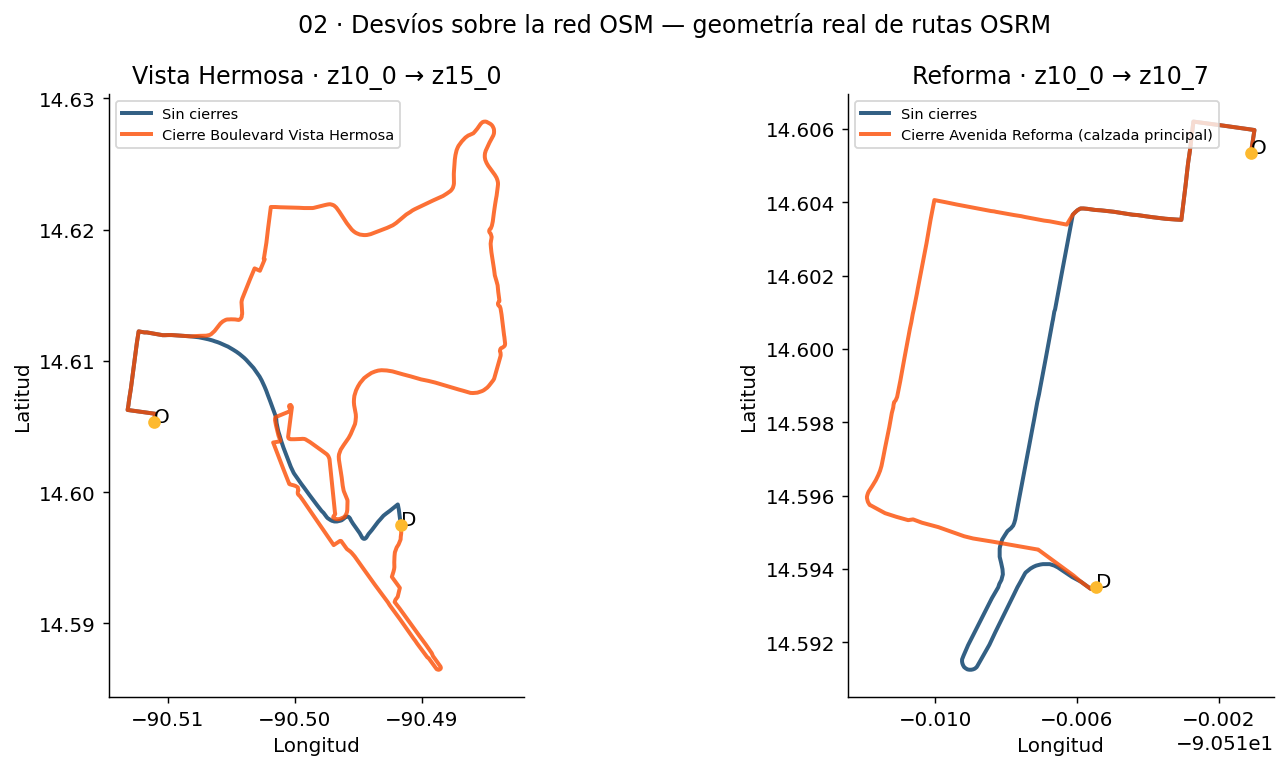

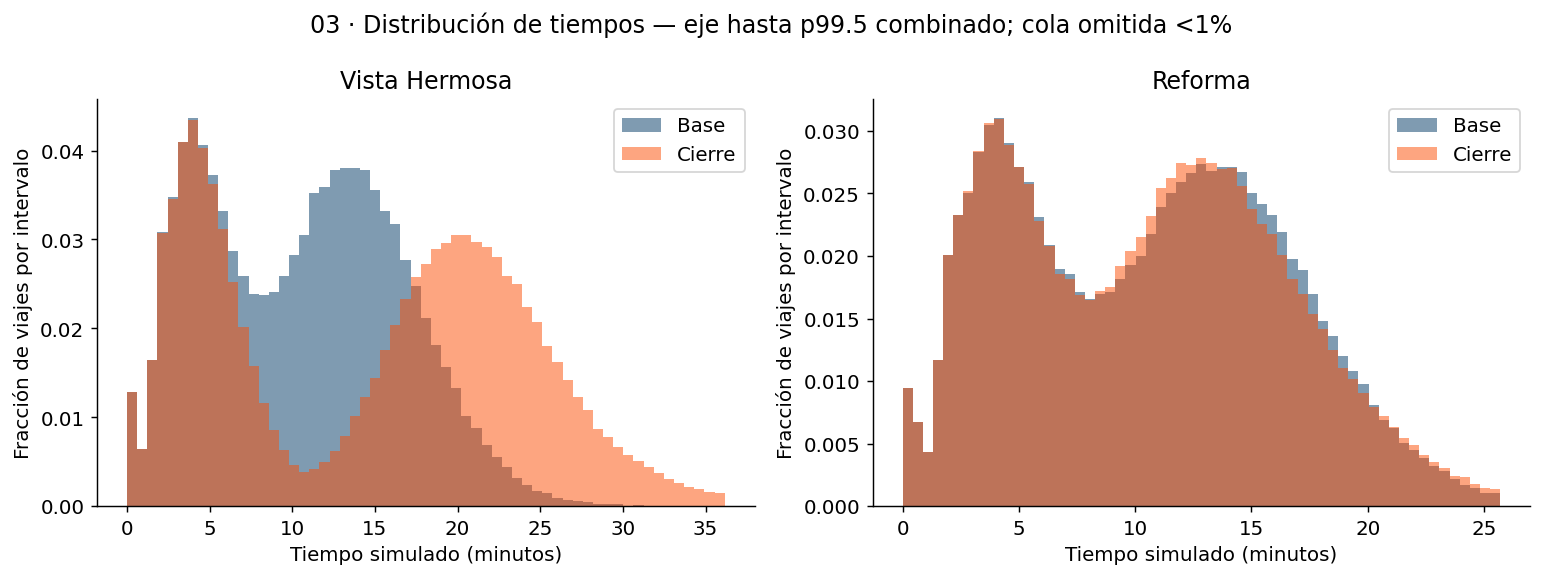

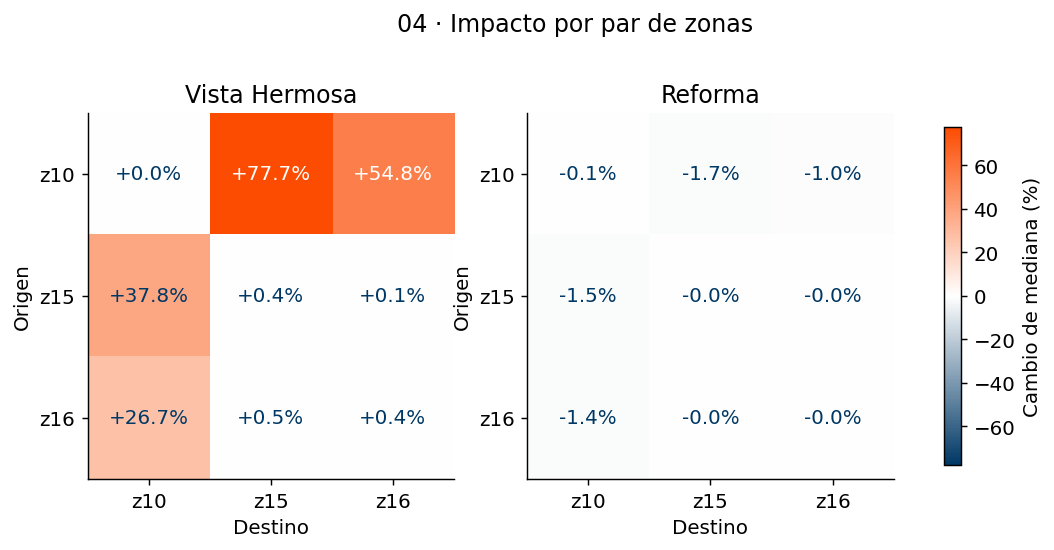

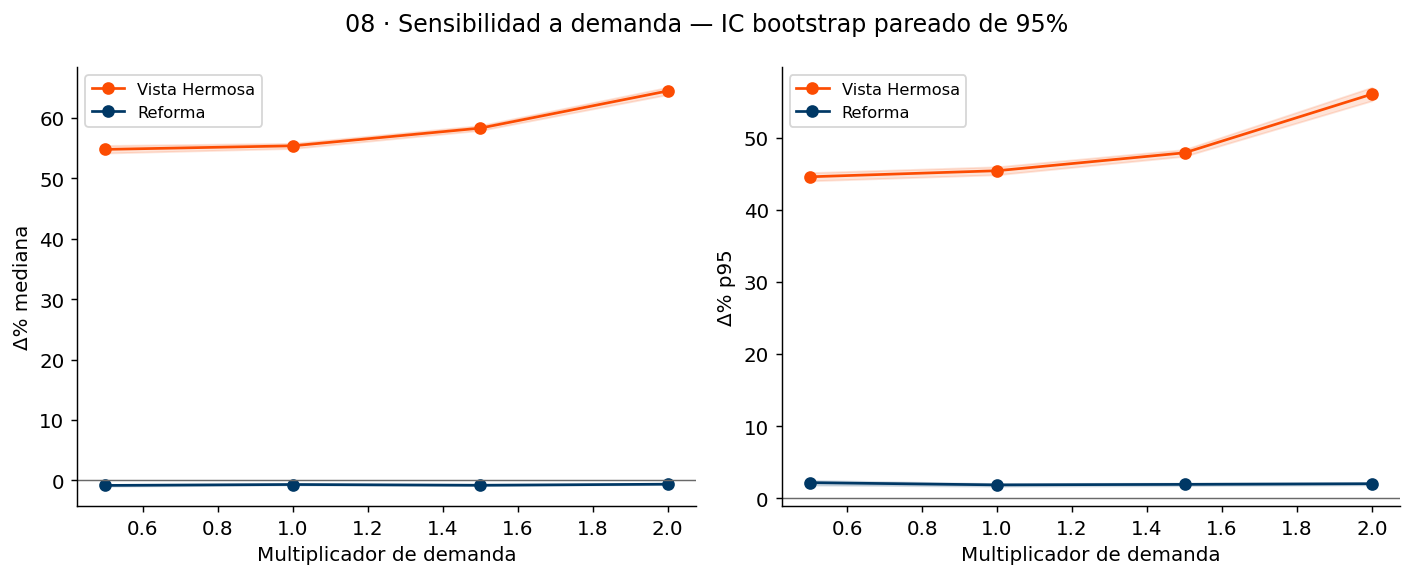

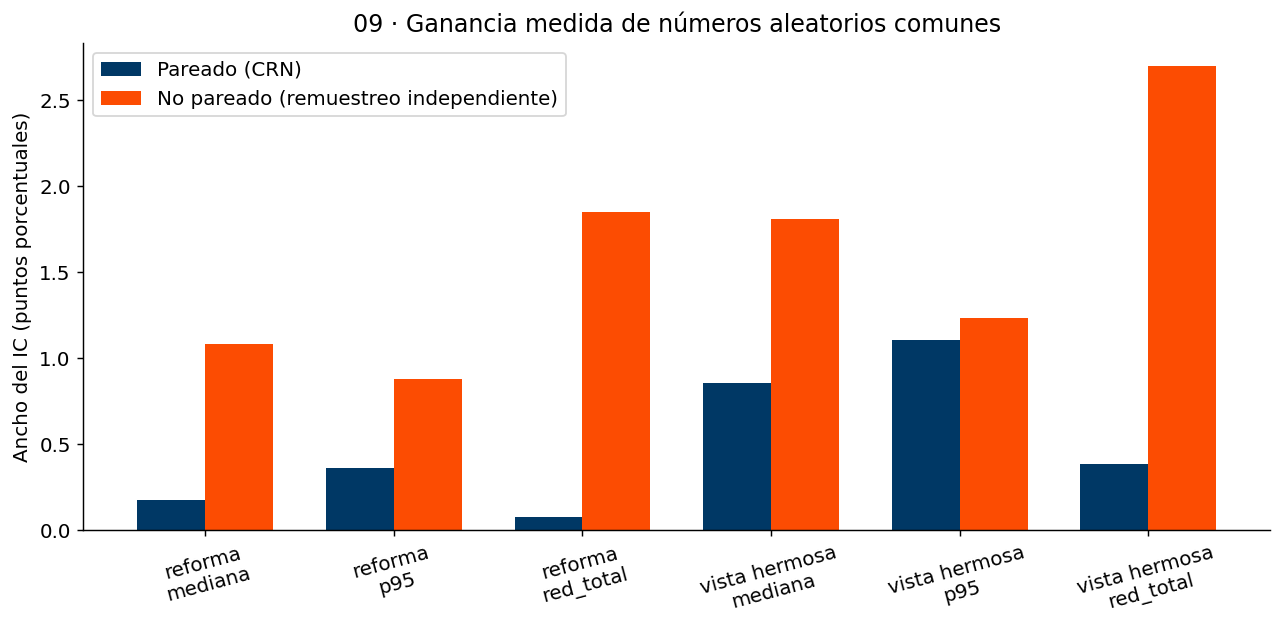

In [2]:
for nombre in ('02_rutas_antes_despues','03_histogramas','04_matriz_zonas','08_sensibilidad_demanda','09_intervalos_pareados'):
    display(Image(filename=str(c.FIGURAS/f'{nombre}.png')))


In [3]:
# Lectura numérica sin imponer el signo esperado del efecto de congestión.
for r in resumen.itertuples():
    diferencia=r.delta_pct-r.delta_libre_pct
    print(f'{r.escenario} / {r.metrica}: Δ {r.delta_pct:+.2f}%; flujo libre con la misma demanda {r.delta_libre_pct:+.2f}%; diferencia {diferencia:+.2f} pp.')
    print(f'  IC 95% pareado [{r.ic_pareado[0]:.2f}, {r.ic_pareado[1]:.2f}]%; reducción de ancho vs. no pareado {r.reduccion_ancho_pct:.1f}%.')
print('Mayor impacto O-D por escenario:')
for esc,m in tablas.items():
    i,j=np.unravel_index(np.nanargmax(m),m.shape)
    print(esc,list(c.ZONAS)[i],'→',list(c.ZONAS)[j],f'{m[i,j]:+.2f}%')


reforma / mediana: Δ -0.68%; flujo libre con la misma demanda +0.09%; diferencia -0.77 pp.
  IC 95% pareado [-0.77, -0.59]%; reducción de ancho vs. no pareado 83.6%.
reforma / p95: Δ +1.86%; flujo libre con la misma demanda +0.89%; diferencia +0.97 pp.
  IC 95% pareado [1.68, 2.04]%; reducción de ancho vs. no pareado 58.9%.
reforma / red_total: Δ +0.00%; flujo libre con la misma demanda +0.81%; diferencia -0.81 pp.
  IC 95% pareado [-0.04, 0.04]%; reducción de ancho vs. no pareado 95.7%.
vista_hermosa / mediana: Δ +55.40%; flujo libre con la misma demanda +47.79%; diferencia +7.61 pp.
  IC 95% pareado [54.96, 55.82]%; reducción de ancho vs. no pareado 52.7%.
vista_hermosa / p95: Δ +45.42%; flujo libre con la misma demanda +38.50%; diferencia +6.92 pp.
  IC 95% pareado [44.87, 45.97]%; reducción de ancho vs. no pareado 10.5%.
vista_hermosa / red_total: Δ +41.72%; flujo libre con la misma demanda +36.02%; diferencia +5.70 pp.
  IC 95% pareado [41.54, 41.92]%; reducción de ancho vs. no pa

In [4]:
componentes=pd.read_csv(c.DERIVADOS/'04_componentes.csv')
g=componentes.groupby(['escenario','etapa'])[['mediana','p95','red_total']].mean()
from simulacion import cociente
for esc in ('vista_hermosa','reforma'):
    print(esc)
    display(pd.DataFrame(cociente(g.loc['base'],g.loc[esc]),index=g.loc[esc].index,columns=g.columns).round(3))


vista_hermosa


,mediana,p95,red_total
etapa,,,
BPR / velocidad,44.588,43.857,36.664
BPR / velocidad + semáforos,55.402,45.424,41.723
OSRM,47.788,38.503,36.024
OSRM / velocidad,43.770,43.104,36.021


reforma


,mediana,p95,red_total
etapa,,,
BPR / velocidad,0.640,1.111,0.815
BPR / velocidad + semáforos,-0.678,1.865,0.002
OSRM,0.090,0.895,0.810
OSRM / velocidad,0.636,1.105,0.809


**Por qué Reforma tiene una mediana ligeramente negativa:** con BPR y velocidades, pero sin demora adicional de semáforos, el cambio es +0,640%. Al sumar las esperas en los nodos de cada ruta pasa a −0,678%. El cambio de signo proviene de este componente del modelo; no es evidencia de que cerrar Reforma mejore el tráfico real. En Vista Hermosa, BPR/velocidad da +44,588% y el modelo completo +55,402%.

La diferencia frente al contrafactual de flujo libre combina BPR, velocidades y demora adicional; no identifica causalmente el aporte exclusivo de congestión. La sensibilidad varía sólo la intensidad de llegadas, manteniendo el resto de supuestos. Las bandas son incertidumbre Monte Carlo condicional al modelo: no incluyen incertidumbre de parámetros, geografía muestreada ni datos OSM.

**Limitaciones:** pool pequeño, pesos supuestos, carriles imputados cuando faltan etiquetas, capacidad sin calibración, semáforos incompletos en OSM, rutas fijas y cohortes estáticas. No hay equilibrio de tráfico, medición de la hora pico real ni demostración de causalidad urbana. Los cocientes pueden retener sesgos que difieran entre escenarios. El siguiente paso de mayor valor es calibrar demanda/capacidades y ampliar el pool, antes de añadir más complejidad al motor.

In [5]:
display(IFrame(src='../figuras/10_mapa_interactivo.html',width='100%',height=950))
print('Abrir para la defensa:',c.FIGURAS/'10_mapa_interactivo.html')


Abrir para la defensa: /Users/yhimp/Desktop/UVG/UVG/semestre 6/ModSim/proyecto-trafico/figuras/10_mapa_interactivo.html
